In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

In [2]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
print("Downloading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)

sample_digit = x_test[0:1]
sample_digit_tf = tf.convert_to_tensor(sample_digit)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
configs = [
    {"padding":"valid","stride":1,"pool":True,  "name":"Valid | S1 | Pool"},
    {"padding":"same","stride":1,"pool":True,   "name":"Same  | S1 | Pool"},
    {"padding":"valid","stride":2,"pool":True,  "name":"Valid | S2 | Pool"},
    {"padding":"same","stride":2,"pool":True,   "name":"Same  | S2 | Pool"},
    {"padding":"same","stride":1,"pool":False,  "name":"Same  | S1 | NoPool"},
    {"padding":"same","stride":2,"pool":False,  "name":"Same  | S2 | NoPool"},
]

results = []
feature_maps_to_plot = []

print("\nStarting Experiments...")


Starting Experiments...


In [6]:
for i, cfg in enumerate(configs):

    # ✅ SAFE internal name (NO special characters)
    cfg_name = f"cfg_{i}"

    # Human-readable name (for display only)
    display_name = cfg["name"]

    # ---- Build model ----
    inputs = layers.Input(shape=(28,28,1), name=f"{cfg_name}_input")

    conv = layers.Conv2D(
        32, (3,3),
        padding=cfg["padding"],
        strides=cfg["stride"],
        activation="relu",
        name=f"{cfg_name}_conv"
    )(inputs)

    feature_shape = conv.shape[1:3]

    x = conv
    if cfg["pool"]:
        x = layers.MaxPooling2D((2,2), name=f"{cfg_name}_pool")(x)

    x = layers.Flatten(name=f"{cfg_name}_flat")(x)
    outputs = layers.Dense(10, activation="softmax", name=f"{cfg_name}_out")(x)

    model = keras.Model(inputs, outputs, name=cfg_name)

    # ---- Params ----
    params = model.count_params()

    # ---- Compile ----
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # ---- Train ----
    epochs = 5
    start = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=256,
        verbose=0,
        validation_split=0.1
    )

    total_time = time.time() - start
    time_per_epoch = total_time / epochs

    _, acc = model.evaluate(x_test, y_test, verbose=0)

    # ---- Feature maps (AFTER training, no retracing) ----
    fmap_model = keras.Model(inputs, conv)
    maps = fmap_model(sample_digit_tf, training=False).numpy()

    # ---- Store results ----
    results.append({
        "Config": display_name,
        "Padding": cfg["padding"],
        "Stride": cfg["stride"],
        "Pool": cfg["pool"],
        "FeatureMap": f"{feature_shape[0]}x{feature_shape[1]}",
        "Params": params,
        "Time/Epoch(s)": round(time_per_epoch, 3),
        "ValAcc": round(history.history["val_accuracy"][-1], 4),
        "TestAcc": round(acc, 4)
    })

    feature_maps_to_plot.append((maps, display_name))



In [7]:
df = pd.DataFrame(results)

print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)
print(df.to_string(index=False))


EXPERIMENT SUMMARY
             Config Padding  Stride  Pool FeatureMap  Params  Time/Epoch(s)  ValAcc  TestAcc
  Valid | S1 | Pool   valid       1  True      26x26   54410         19.823  0.9817   0.9783
  Same  | S1 | Pool    same       1  True      28x28   63050         19.686  0.9827   0.9774
  Valid | S2 | Pool   valid       2  True      13x13   11850          5.202  0.9712   0.9633
  Same  | S2 | Pool    same       2  True      14x14   16010          7.567  0.9698   0.9635
Same  | S1 | NoPool    same       1 False      28x28  251210         18.650  0.9837   0.9793
Same  | S2 | NoPool    same       2 False      14x14   63050          4.941  0.9747   0.9698


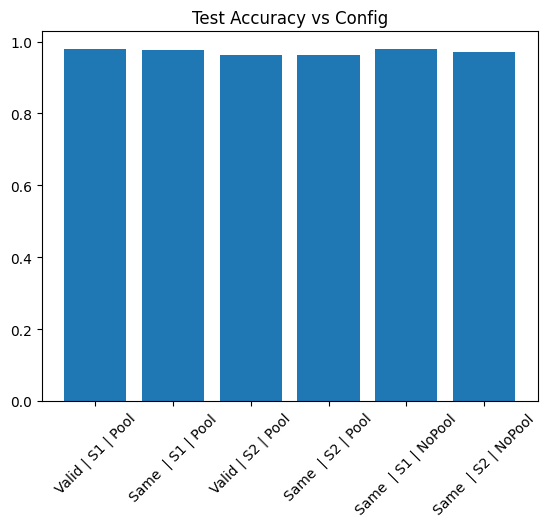

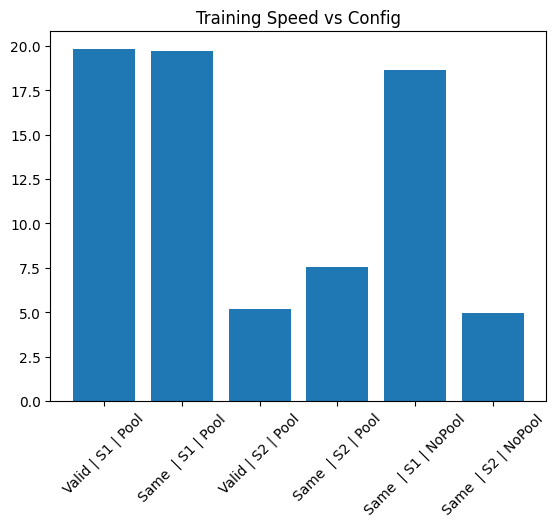

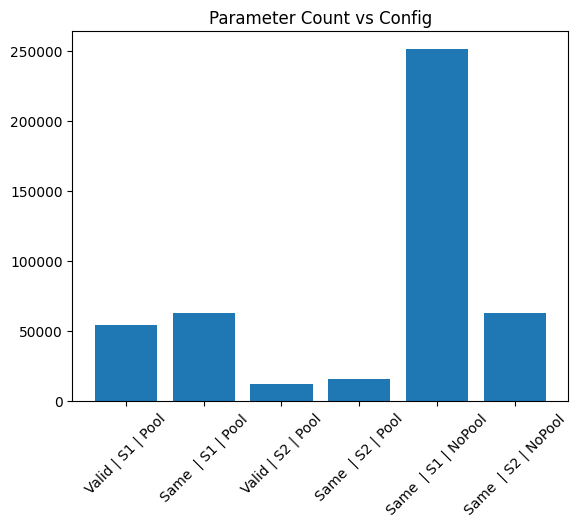

In [8]:
plt.figure()
plt.bar(df["Config"], df["TestAcc"])
plt.xticks(rotation=45)
plt.title("Test Accuracy vs Config")
plt.show()

plt.figure()
plt.bar(df["Config"], df["Time/Epoch(s)"])
plt.xticks(rotation=45)
plt.title("Training Speed vs Config")
plt.show()

plt.figure()
plt.bar(df["Config"], df["Params"])
plt.xticks(rotation=45)
plt.title("Parameter Count vs Config")
plt.show()

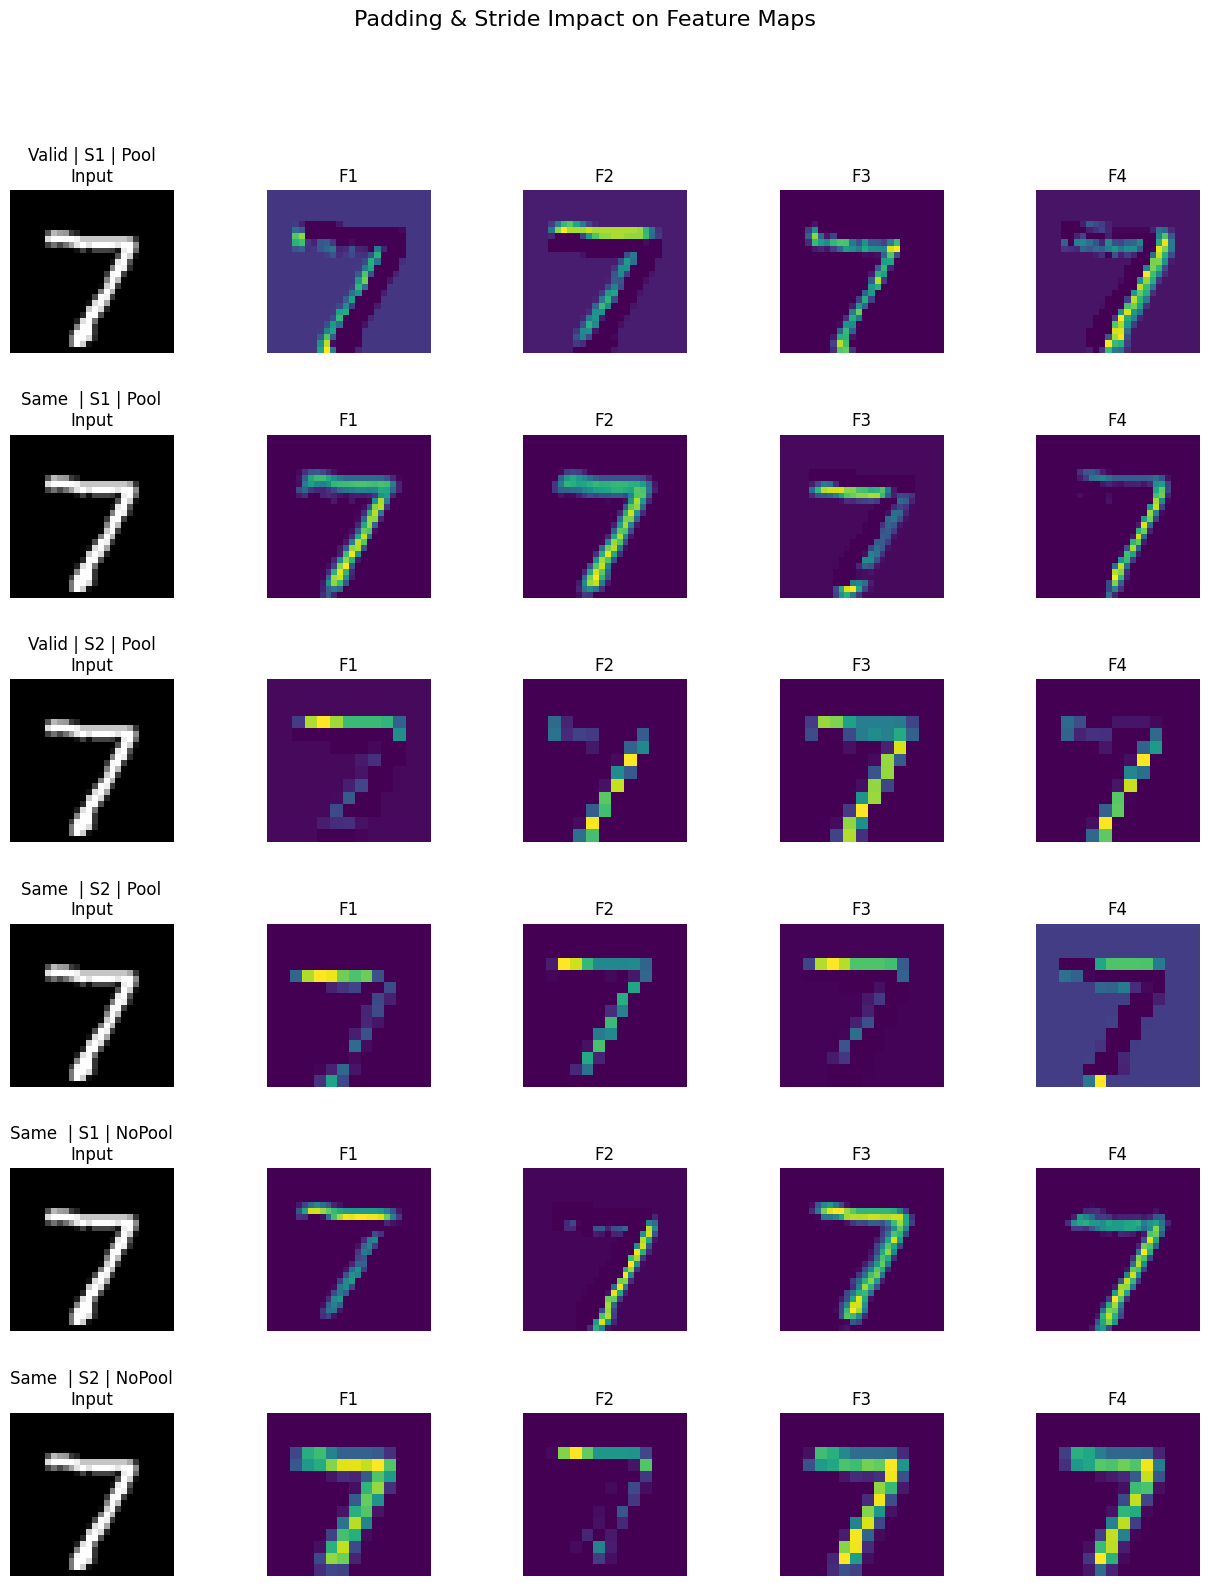

In [9]:
rows = len(feature_maps_to_plot)
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(16, 3*rows))
plt.subplots_adjust(hspace=0.5)

for i, (maps, name) in enumerate(feature_maps_to_plot):

    axes[i,0].imshow(sample_digit[0,:,:,0], cmap="gray")
    axes[i,0].set_title(f"{name}\nInput")
    axes[i,0].axis("off")

    for j in range(1, cols):
        axes[i,j].imshow(maps[0,:,:,j], cmap="viridis")
        axes[i,j].set_title(f"F{j}")
        axes[i,j].axis("off")

plt.suptitle("Padding & Stride Impact on Feature Maps", fontsize=16)
plt.show()